In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Note: This script retains the original thesis development paths and is not intended
# to be executed in the public repository without access to the private data environment.

MAIN_DIR = Path("/Users/chanyoungwoo/Thesis/ATE_CATE")
VI_H1_FP = MAIN_DIR / "Model_New_horizon_1/csf_variable_importance.csv"
VI_H2_FP = MAIN_DIR / "Model_New_horizon_2/csf_variable_importance.csv"
VI_H3_FP = MAIN_DIR / "Model_New_horizon_3/csf_variable_importance.csv"
OUT_DIR = MAIN_DIR / "RESULTS/PLOTS"

vi_h1 = pd.read_csv(VI_H1_FP)
vi_h2 = pd.read_csv(VI_H2_FP)
vi_h3 = pd.read_csv(VI_H3_FP)

In [29]:
vi_h1['importance'] /= vi_h1['importance'].sum()
vi_h2['importance'] /= vi_h2['importance'].sum()
vi_h3['importance'] /= vi_h3['importance'].sum()

df_vi = (vi_h1.rename(columns={'importance': 'H1'})
               .merge(vi_h2.rename(columns={'importance': 'H2'}), on='feature')
               .merge(vi_h3.rename(columns={'importance': 'H3'}), on='feature'))

In [30]:
name_map = {
    "CAN_DGN_Kidney Diabetic or metabolic nephropathy": "Diagnosis:\nDiabetic/Metabolic Nephropathy",
    "CAN_DIAB_TY_No": "No Diabetes\nat Listing",
    "CAN_MAX_PCT_SCLER_LT10": "Max Acceptable\nGlomerular Sclerosis",
    "MAX_CPRA": "Calculated PRA",
    "CAN_FUNCTN_STAT_Independent with effort": "Functional Status:\nIndependent with Effort",
    "CAN_TOT_ALBUMIN": "Total Serum Albumin",
    "CAN_DIAB_TY_Unknown": "Diabetes Status Unknown",
    "CAN_MED_COND_MISSING": "Medical Condition Missing",
    "CAN_MED_COND_Not Hospitalized": "Not Hospitalized at Listing",
    "CAN_FUNCTN_STAT_No Assistance": "Functional Status:\nNo Assistance",
    "CAN_DRUG_TREAT_COPD": "Drug Treated COPD",
    "CAN_RACE_White": "Race: White"
}
df_vi['variable_nice'] = df_vi['feature'].map(name_map).fillna(df_vi['feature'])


In [31]:
df_vi['avg_importance'] = df_vi[['H1', 'H2', 'H3']].mean(axis=1)
top_vars = df_vi.nlargest(10, 'avg_importance')

top_vars = top_vars.sort_values('H1', ascending=False)

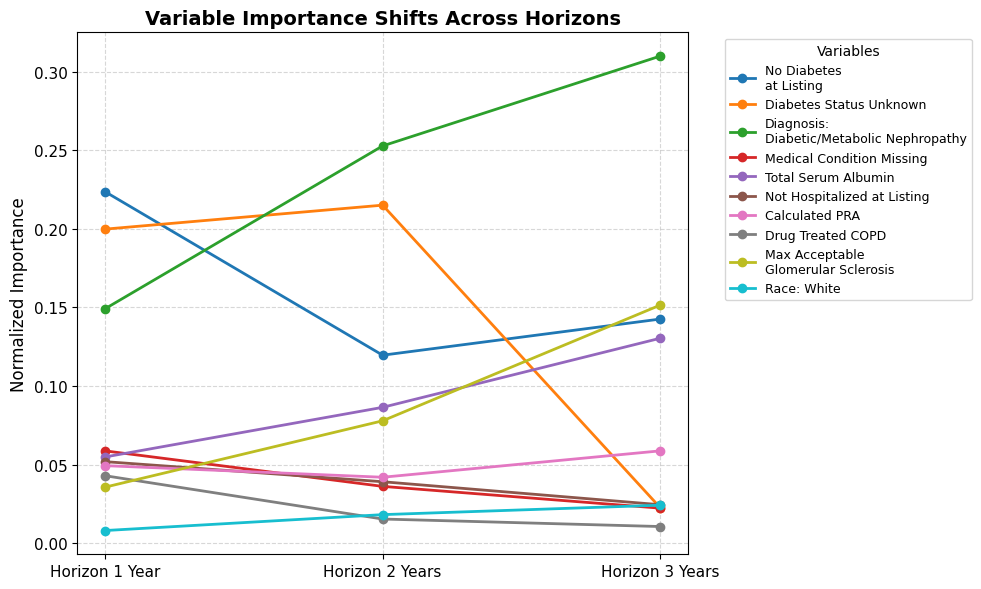

In [32]:
plt.figure(figsize=(10, 6))  

for _, row in top_vars.iterrows():
    plt.plot([1, 2, 3], [row['H1'], row['H2'], row['H3']],
             marker='o', linewidth=2, label=row['variable_nice'])

plt.xticks([1, 2, 3], ['Horizon 1 Year', 'Horizon 2 Years', 'Horizon 3 Years'], fontsize=11)
plt.yticks(fontsize=11)
plt.ylabel("Normalized Importance", fontsize=12)
plt.title("Variable Importance Shifts Across Horizons", fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(title="Variables", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, title_fontsize=10)

plt.tight_layout()

plt.savefig(OUT_DIR / "variable_importance_shift_with_legend.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "variable_importance_shift_with_legend.pdf", dpi=300, bbox_inches="tight")

plt.show()